In [146]:
import pandas as pd

In [147]:
df = pd.read_csv(r"C:\DriveD\fyp\datasets\illness_dataset.csv")

In [148]:
df.loc[df['Disease'] == 'No illness'] = 0

In [149]:
df['Disease'] = df['Disease'].replace(0, 'No illness')

In [150]:
df.head()

,Disease,muscle_tension,low_energy,sleep_disturbances,changes_in_weight,difficulty_concentrating,feeling_of_worthless,low_mood,irritability,thoughts_of_death,...,inability_to_recall_important_personal_information,memory_loss_typically_related_to_trauma,sudden_onset_of_amnesia,gaps_in_memory_for_long_periods_of_time,wandering,loss_of_identity,emotional_numbness,trouble_remembering_daily_tasks,anxiety_related_to_memory_loss,confusion
0,Borderline Personality Disorder,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Eating Disorder,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Major Depressive Disorder,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,Substance Use Disorder,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ADHD (Attention Deficit Hyperactivity Disorder),0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [151]:
from sklearn.preprocessing import LabelEncoder

In [152]:
le = LabelEncoder()
df['target'] = le.fit_transform(df['Disease'])

In [153]:
from sklearn.model_selection import train_test_split

In [154]:
X = df.drop(['Disease', 'target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [155]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [156]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), X.columns)
    ]
)

In [157]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

In [158]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": MultinomialNB()
}

In [159]:
from sklearn.pipeline import Pipeline

In [160]:
pipelines = {
    name: Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    for name, clf in models.items()
}

In [161]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix

In [162]:
results = []
for name, pipe in pipelines.items():
    try:
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted')
        results.append((name, acc, prec, f1))
    except Exception as e:
        results.append((name, str(e), None, None))

In [163]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "F1 Score"])
results_df.sort_values(by="F1 Score", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)

In [164]:
results_df

,Model,Accuracy,Precision,F1 Score
0,Random Forest,0.983143,0.983325,0.983142
1,Logistic Regression,0.964479,0.964855,0.964470
2,Naive Bayes,Negative values in data passed to MultinomialN...,NaN,NaN


In [165]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [166]:
best_model = pipelines["Random Forest"]
y_pred_best = best_model.predict(X_test)

In [167]:
cm = confusion_matrix(y_test, y_pred_best)
class_names = le.classes_

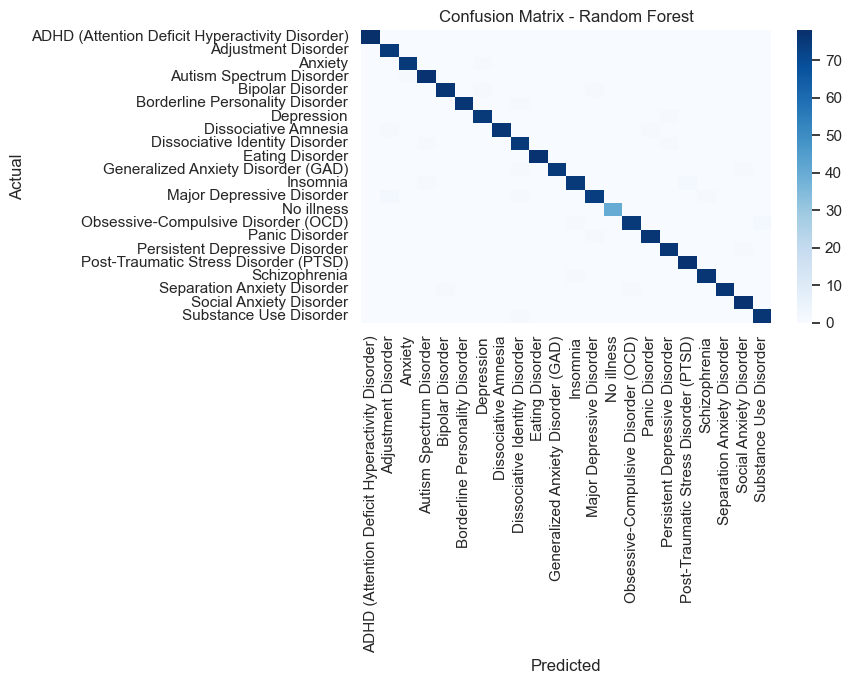

In [168]:
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [169]:
from sklearn.metrics import classification_report

In [170]:
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

                                                 precision    recall  f1-score   support

ADHD (Attention Deficit Hyperactivity Disorder)       1.00      1.00      1.00        78
                            Adjustment Disorder       0.96      1.00      0.98        75
                                        Anxiety       0.99      0.99      0.99        76
                       Autism Spectrum Disorder       0.97      0.99      0.98        78
                               Bipolar Disorder       0.99      0.97      0.98        78
                Borderline Personality Disorder       1.00      0.99      0.99        77
                                     Depression       0.97      0.99      0.98        76
                           Dissociative Amnesia       1.00      0.97      0.99        78
                 Dissociative Identity Disorder       0.95      0.97      0.96        77
                                Eating Disorder       1.00      1.00      1.00        77
             General

In [171]:
# Convert numeric columns to float and remove rows with invalid values
numeric_cols = ["Accuracy", "Precision", "F1 Score"]
results_df_clean = results_df.copy()

# Convert numeric columns to float, coerce errors (e.g., "error" becomes NaN)
for col in numeric_cols:
    results_df_clean[col] = pd.to_numeric(results_df_clean[col], errors='coerce')

# Drop rows where any metric is NaN
results_df_clean = results_df_clean.dropna(subset=numeric_cols)

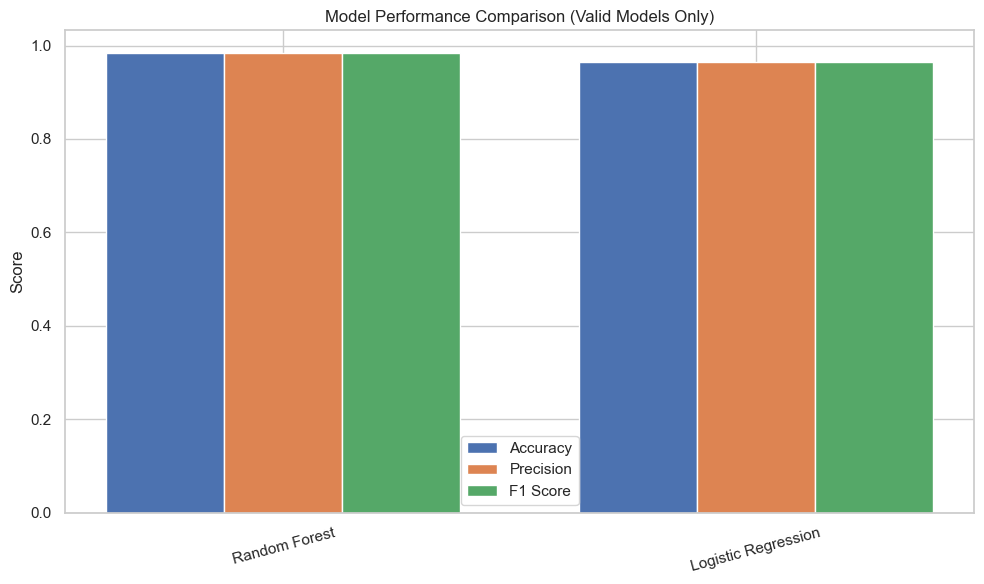

In [172]:
bar_width = 0.25
x = np.arange(len(results_df_clean))

plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, results_df_clean["Accuracy"], width=bar_width, label='Accuracy')
plt.bar(x, results_df_clean["Precision"], width=bar_width, label='Precision')
plt.bar(x + bar_width, results_df_clean["F1 Score"], width=bar_width, label='F1 Score')

plt.xticks(ticks=x, labels=results_df_clean["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Model Performance Comparison (Valid Models Only)")
plt.legend()
plt.tight_layout()
plt.show()

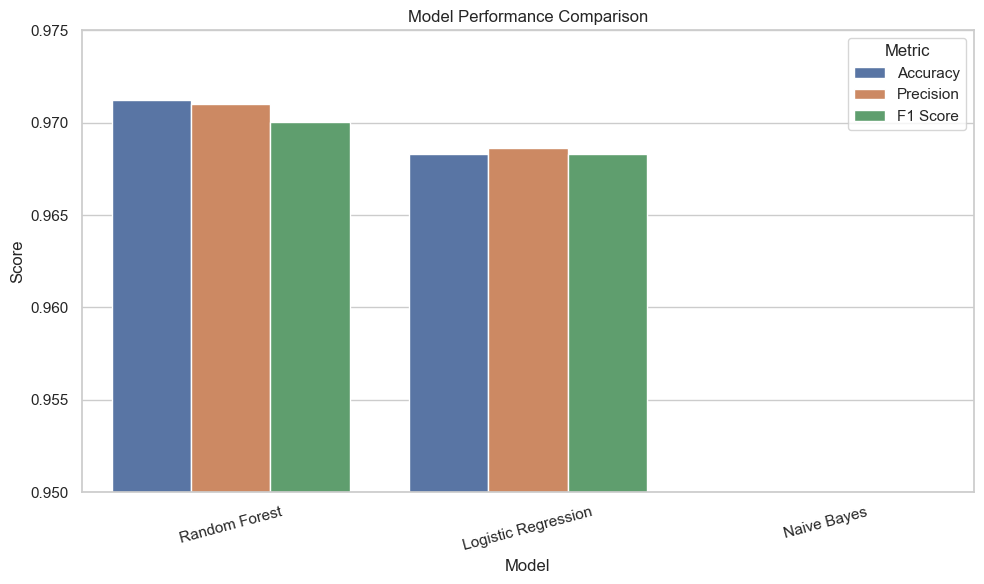

In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the data
data = {
    'Model': ['Random Forest', 'Logistic Regression', 'Naive Bayes'],
    'Accuracy': [0.971221, 0.968326, np.nan],
    'Precision': [0.971001, 0.968649, np.nan],
    'F1 Score': [0.970012, 0.968302, np.nan]
}

# Create DataFrame
df = pd.DataFrame(data)

# Convert all numeric columns to float (if not already)
df[['Accuracy', 'Precision', 'F1 Score']] = df[['Accuracy', 'Precision', 'F1 Score']].astype(float)

# Set style
sns.set(style="whitegrid")

# Melt DataFrame for seaborn
df_melted = df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric')
plt.title('Model Performance Comparison')
plt.ylim(0.95, 0.975)
plt.ylabel('Score')
plt.xlabel('Model')
plt.legend(title='Metric')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


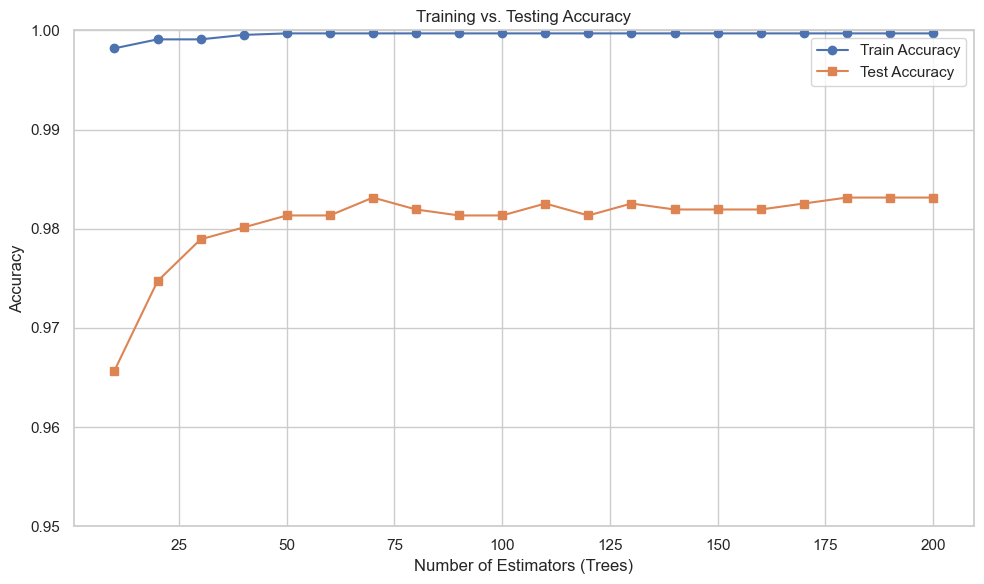

In [174]:
# Track accuracy
estimators_range = range(10, 201, 10)
train_accuracies = []
test_accuracies = []

for n in estimators_range:
    model = RandomForestClassifier(n_estimators=n, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, model.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, model.predict(X_test)))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(estimators_range, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(estimators_range, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Estimators (Trees)')
plt.ylabel('Accuracy')
plt.title('Training vs. Testing Accuracy')
plt.legend()
plt.grid(True)
# Set y-axis range and ticks
plt.ylim(0.95, 1.00)
plt.yticks([0.95, 0.96, 0.97, 0.98, 0.99, 1.00])
plt.tight_layout()
plt.show()
